# Árboles de Decisión y Random Forest

En este cuaderno vamos a trabajar con dos modelos de aprendizaje supervisado que están muy relacionados entre sí: los **Árboles de Decisión** y los **Random Forest**.

Primero estudiaremos cómo funciona un árbol de decisión individual. Veremos que este tipo de modelo toma decisiones mediante una secuencia de preguntas o reglas, hasta llegar a una clasificación final. También analizaremos una de sus principales ventajas: su facilidad de interpretación y visualización.

Luego veremos que los árboles de decisión, aunque son muy claros y útiles, pueden tener un problema importante: si crecen demasiado, pueden ajustarse en exceso a los datos de entrenamiento. Este fenómeno se conoce como **sobreajuste** u **overfitting**.

A partir de esa limitación, introduciremos el modelo **Random Forest**, que combina muchos árboles de decisión para construir un modelo más robusto. La idea central será pasar de un único árbol a un bosque de árboles, donde cada árbol aporta una predicción y el modelo final decide por votación.

Durante el recorrido vamos a entrenar modelos, visualizar árboles, evaluar resultados con métricas conocidas y comparar el comportamiento de un árbol individual con el de un bosque aleatorio.


## Objetivos del cuaderno

Al finalizar este cuaderno, se espera que puedas:

- Comprender la lógica general de un **Árbol de Decisión**.
- Reconocer los elementos principales de un árbol: nodo raíz, nodos internos, ramas, hojas y profundidad.
- Entrenar un modelo usando `DecisionTreeClassifier`.
- Visualizar un árbol de decisión con `plot_tree`.
- Evaluar el rendimiento de un árbol usando métricas conocidas.
- Analizar el problema del **sobreajuste** en árboles demasiado profundos.
- Comprender la idea general de un **Random Forest** como combinación de muchos árboles.
- Entrenar y evaluar un modelo usando `RandomForestClassifier`.
- Comparar el rendimiento de un árbol individual con el de un bosque aleatorio.
- Interpretar la importancia de las variables dentro de un Random Forest.

## Dataset que vamos a utilizar

Para este cuaderno vamos a utilizar el dataset **Breast Cancer Wisconsin**, incluido dentro de la librería `scikit-learn`.

Este conjunto de datos contiene mediciones realizadas sobre tumores mamarios y tiene como objetivo clasificar cada caso en una de dos categorías posibles: **benigno** o **maligno**.

Elegimos este dataset porque es adecuado para trabajar con modelos de clasificación, no requiere descarga externa y ya viene preparado para ser usado desde Python. Esto nos permite concentrarnos en el objetivo principal del cuaderno: comprender cómo funcionan los Árboles de Decisión y cómo esa idea se extiende al modelo Random Forest.

A lo largo del cuaderno usaremos las mediciones disponibles como **variables predictoras** y la clasificación del tumor como **variable objetivo**.

## Herramientas específicas

En esta primera celda de código vamos a importar las librerías generales de trabajo y, especialmente, algunos objetos de `scikit-learn` que usaremos durante el cuaderno.

Para los modelos principales vamos a utilizar:

- `DecisionTreeClassifier`, que permite crear y entrenar Árboles de Decisión para clasificación.
- `plot_tree`, que permite visualizar gráficamente la estructura de un árbol entrenado.
- `RandomForestClassifier`, que permite crear y entrenar un bosque aleatorio formado por muchos árboles de decisión.

También importaremos funciones para dividir los datos en entrenamiento y prueba, y herramientas para evaluar los resultados del modelo con métricas conocidas.

In [30]:
# ---------------------------------------------------------
# Importación de librerías
# ---------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Carga del dataset

Ahora vamos a cargar el dataset **Breast Cancer Wisconsin** desde `scikit-learn`.

Este dataset viene organizado en dos partes principales:

- Los **datos de entrada**, que contienen las mediciones de cada caso.
- La **variable objetivo**, que indica la clase a predecir.

Para trabajar con mayor comodidad, vamos a convertir los datos en un `DataFrame` de Pandas. De esta manera podremos visualizar las columnas, revisar algunas filas y preparar las variables predictoras y la variable objetivo.

In [31]:
# ---------------------------------------------------------
# Carga del dataset Breast Cancer Wisconsin
# ---------------------------------------------------------

# Cargamos el dataset desde scikit-learn
datos = load_breast_cancer()

# Creamos un DataFrame con las variables predictoras
df = pd.DataFrame(datos.data, columns=datos.feature_names)

# Agregamos la variable objetivo al DataFrame
df["target"] = datos.target

# Mostramos las primeras filas
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Primer vistazo al dataset

El dataset quedó cargado correctamente en un `DataFrame`.

Cada fila representa un caso y cada columna contiene una medición asociada al tumor. La última columna, llamada `target`, contiene la clase que queremos predecir.

En este dataset, la variable objetivo tiene dos valores posibles:

- `0`: tumor maligno.
- `1`: tumor benigno.

A continuación vamos a revisar la cantidad de filas y columnas, los nombres de las clases y la distribución de la variable objetivo.

In [32]:
# ---------------------------------------------------------
# Exploración general del dataset
# ---------------------------------------------------------

# Mostramos la cantidad de filas y columnas
print("Dimensiones del DataFrame:")
print(df.shape)

print("\nNombres de las clases:")
print(datos.target_names)

print("\nCantidad de casos por clase:")
print(df["target"].value_counts())

print("\nCantidad de casos por clase, usando los nombres originales:")
print(pd.Series(datos.target).map({
    0: datos.target_names[0],
    1: datos.target_names[1]
}).value_counts())

Dimensiones del DataFrame:
(569, 31)

Nombres de las clases:
['malignant' 'benign']

Cantidad de casos por clase:
target
1    357
0    212
Name: count, dtype: int64

Cantidad de casos por clase, usando los nombres originales:
benign       357
malignant    212
Name: count, dtype: int64


El dataset contiene **569 registros** y **31 columnas**. De esas columnas, 30 corresponden a mediciones del tumor y una corresponde a la variable objetivo (`target`).

La variable objetivo tiene dos clases:

- `0`: tumor maligno.
- `1`: tumor benigno.

También observamos que hay más casos benignos que malignos. Por eso, al separar los datos en entrenamiento y prueba, vamos a usar `stratify=y`, para conservar una proporción similar de clases en ambos conjuntos.

## Separación entre variables predictoras y variable objetivo

Como en cuadernos anteriores, vamos a separar el dataset en dos partes:

- `X`: contiene las variables predictoras, es decir, las mediciones que usará el modelo para aprender.
- `y`: contiene la variable objetivo, es decir, la clase que queremos predecir.

En este caso, todas las columnas excepto `target` serán utilizadas como variables predictoras.

In [33]:
# ---------------------------------------------------------
# Separación de variables predictoras y variable objetivo
# ---------------------------------------------------------

# Variables predictoras
X = df.drop("target", axis=1)

# Variable objetivo
y = df["target"]

# Mostramos las dimensiones resultantes
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (569, 30)
Dimensiones de y: (569,)


## Separación en entrenamiento y prueba

Ahora vamos a dividir los datos en dos conjuntos:

- Un conjunto de **entrenamiento**, que el modelo usará para aprender.
- Un conjunto de **prueba**, que usaremos para evaluar cómo se comporta el modelo con datos que no vio durante el entrenamiento.

Usaremos `stratify=y` para conservar una proporción similar de tumores benignos y malignos en ambos conjuntos.

In [34]:
# ---------------------------------------------------------
# Separación en entrenamiento y prueba
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Mostramos las dimensiones de cada conjunto
print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de y_test:", y_test.shape)

Dimensiones de X_train: (455, 30)
Dimensiones de X_test: (114, 30)
Dimensiones de y_train: (455,)
Dimensiones de y_test: (114,)


## ¿Qué es un Árbol de Decisión?

Un **Árbol de Decisión** es un modelo de aprendizaje supervisado que toma decisiones mediante una secuencia de preguntas.

La idea general es parecida a seguir un camino de decisiones del tipo:

**si se cumple una condición, voy por una rama; si no se cumple, voy por otra.**

El árbol comienza en un **nodo raíz**, donde se realiza la primera pregunta. Luego se divide en **ramas**, que llevan a nuevos **nodos internos**, donde se hacen nuevas preguntas. Finalmente, el recorrido termina en una **hoja**, que contiene la predicción del modelo.

En un problema de clasificación, como el que estamos trabajando, cada hoja representa una clase posible. En este caso, el árbol intentará predecir si un tumor es **maligno** o **benigno** a partir de sus mediciones.

Una ventaja importante de los árboles de decisión es que son modelos bastante interpretables: podemos visualizar su estructura y seguir el camino de una predicción paso a paso.

## Entrenamiento de un primer Árbol de Decisión

Vamos a entrenar un primer modelo usando `DecisionTreeClassifier`.

Para comenzar, limitaremos la profundidad del árbol con `max_depth=3`. Esto significa que el árbol podrá hacer solo una cantidad acotada de divisiones antes de llegar a sus hojas.

Esta decisión no busca todavía obtener el mejor modelo posible, sino construir un árbol suficientemente simple como para poder visualizarlo y entender cómo toma decisiones.

In [35]:
# ---------------------------------------------------------
# Entrenamiento de un primer Árbol de Decisión
# ---------------------------------------------------------

arbol_simple = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

# Entrenamos el modelo con los datos de entrenamiento
arbol_simple.fit(X_train, y_train)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


## Visualización del Árbol de Decisión

Una de las ventajas de los Árboles de Decisión es que podemos representar gráficamente su estructura.

En el gráfico vamos a poder observar:

- qué variable se evalúa en cada nodo,
- qué condición se utiliza para dividir los datos,
- cuántos registros llegan a cada nodo,
- qué tan mezcladas están las clases en cada división,
- y qué clase predice cada hoja.

Como entrenamos un árbol con `max_depth=3`, la visualización será relativamente simple y podremos leerla con mayor facilidad.

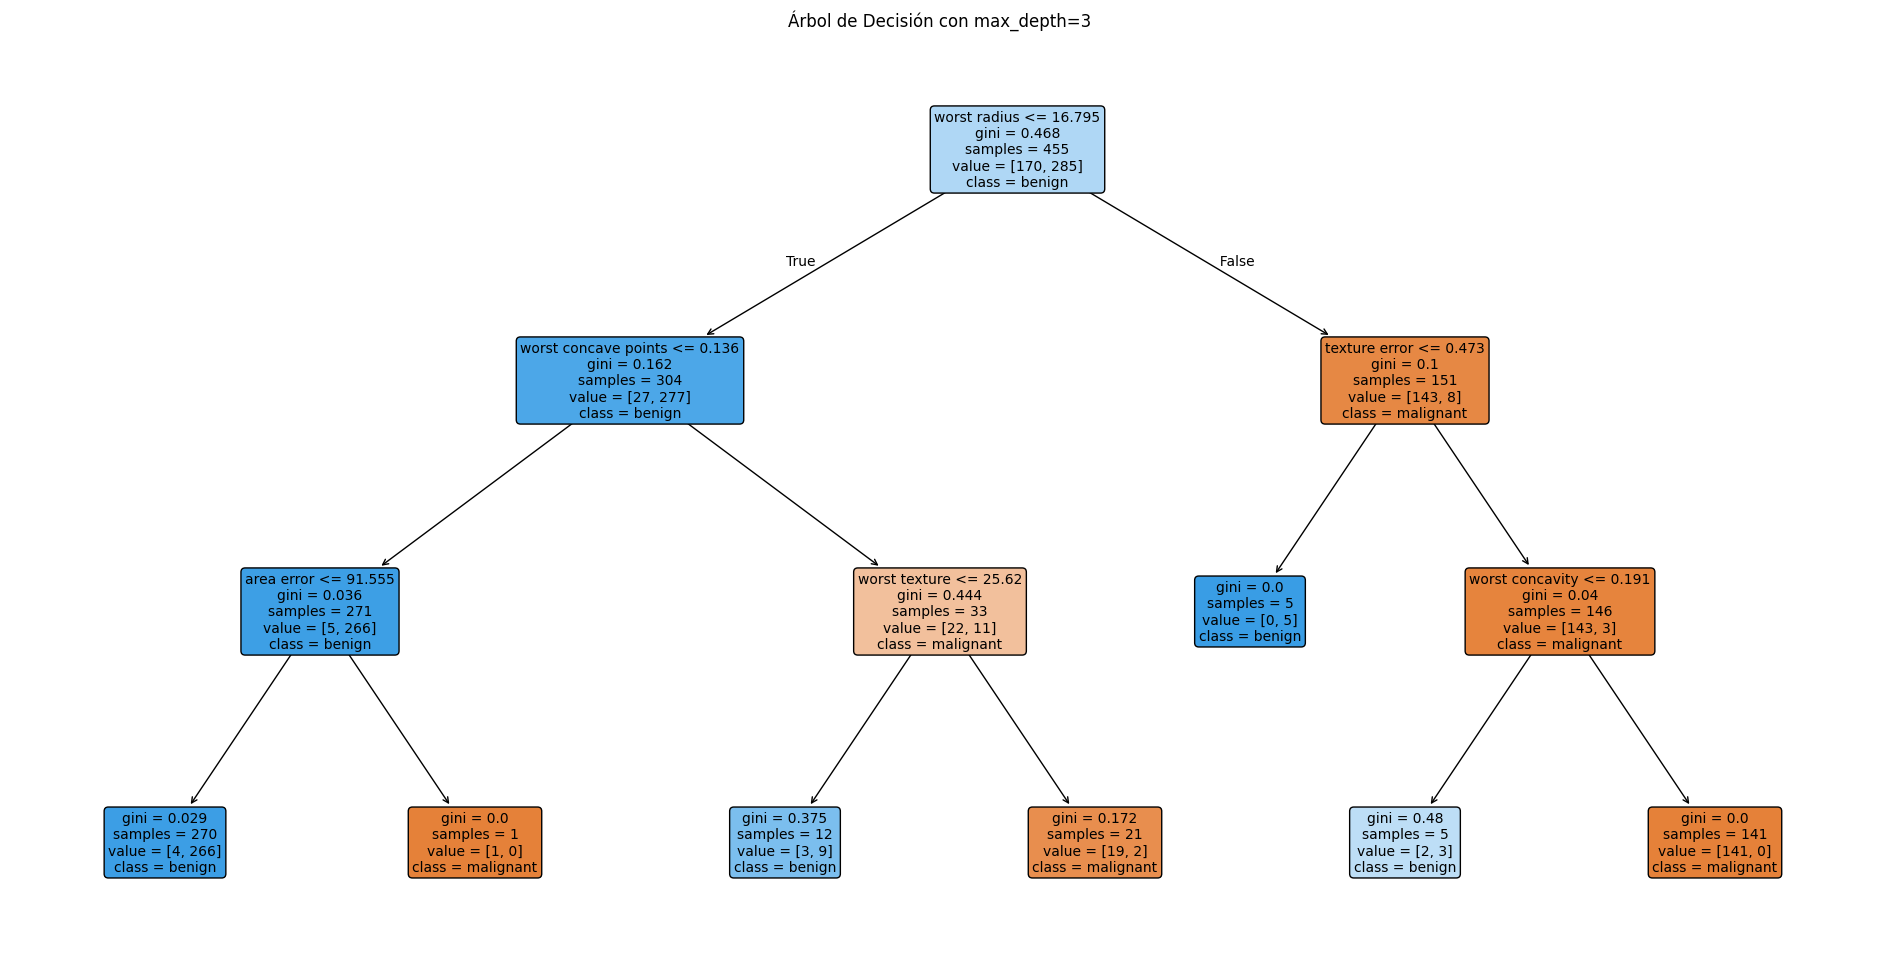

In [36]:
# ---------------------------------------------------------
# Visualización del Árbol de Decisión
# ---------------------------------------------------------

plt.figure(figsize=(24, 12))

plot_tree(
    arbol_simple,
    feature_names=X.columns,
    class_names=datos.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Árbol de Decisión con max_depth=3")
plt.show()

## Cómo leer el árbol visualizado

El gráfico anterior muestra la estructura del árbol entrenado.

Cada recuadro representa un **nodo** del árbol. En cada nodo podemos leer información importante:

- La primera línea muestra la **condición** que evalúa el árbol.
- `gini` indica el nivel de impureza del nodo. Un valor cercano a 0 significa que el nodo contiene casos casi todos de una misma clase.
- `samples` indica cuántos registros llegaron a ese nodo.
- `value` muestra cuántos casos de cada clase llegaron a ese nodo. En este gráfico, el primer número corresponde a `malignant` y el segundo a `benign`, siguiendo el orden de `datos.target_names`.
- `class` indica cuál es la clase mayoritaria en ese nodo y, por lo tanto, la predicción que haría el modelo allí.

El recorrido comienza en el nodo superior, llamado **nodo raíz**. Desde allí, el árbol evalúa una condición. Si la condición se cumple, sigue por la rama izquierda; si no se cumple, sigue por la rama derecha.

En este caso, la primera pregunta que hace el árbol es sobre la variable `worst radius`. A partir de esa primera división, el modelo sigue realizando nuevas preguntas hasta llegar a una hoja final, donde se obtiene la predicción.

## Interpretación de una ruta de decisión

Una forma de entender un Árbol de Decisión es seguir una ruta completa desde el nodo raíz hasta una hoja.

Por ejemplo, podemos observar una ruta posible del árbol anterior:

1. Primero, el modelo evalúa si `worst radius <= 16.795`.
2. Si esa condición se cumple, avanza por la rama izquierda.
3. Luego evalúa si `worst concave points <= 0.136`.
4. Si esa condición también se cumple, evalúa si `area error <= 91.555`.
5. Finalmente, llega a una hoja donde la clase mayoritaria es `benign`.

Esa ruta puede leerse como una regla aproximada:

> Si el radio más desfavorable del tumor es menor o igual a cierto valor, los puntos cóncavos más desfavorables también son bajos, y el error de área se mantiene por debajo de cierto umbral, entonces el modelo llega a una hoja donde predominan los casos benignos, y por eso clasifica el caso como `benign`.

Esta lectura paso a paso es una de las razones por las que los Árboles de Decisión son modelos fáciles de interpretar y comunicar.

## Evaluación del Árbol de Decisión

Ahora vamos a evaluar el rendimiento del árbol con los datos de prueba.

Para eso, primero usaremos el modelo entrenado para generar predicciones sobre `X_test`. Luego compararemos esas predicciones con los valores reales de `y_test`.

Vamos a utilizar métricas conocidas:

- `accuracy`, para medir la proporción general de aciertos.
- `precision`, `recall` y `f1-score`, mediante `classification_report`.
- matriz de confusión, para observar aciertos y errores por clase.

Accuracy del Árbol de Decisión simple: 0.9385964912280702

Reporte de clasificación:
              precision    recall  f1-score   support

   malignant       0.93      0.90      0.92        42
      benign       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



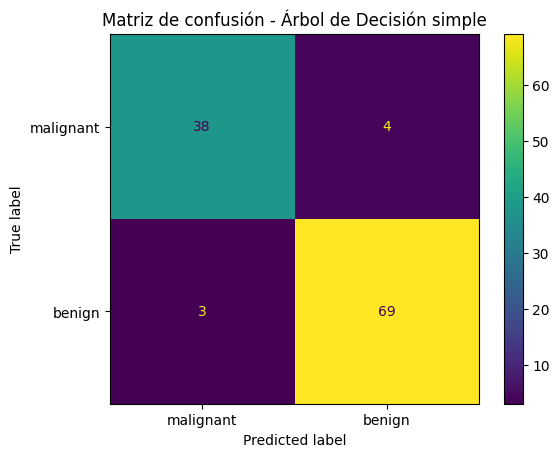

In [37]:
# ---------------------------------------------------------
# Evaluación del Árbol de Decisión
# ---------------------------------------------------------

# Generamos predicciones sobre los datos de prueba
y_pred_arbol_simple = arbol_simple.predict(X_test)

# Calculamos el accuracy
accuracy_arbol_simple = accuracy_score(y_test, y_pred_arbol_simple)

print("Accuracy del Árbol de Decisión simple:", accuracy_arbol_simple)

print("\nReporte de clasificación:")
print(classification_report(
    y_test,
    y_pred_arbol_simple,
    target_names=datos.target_names
))

# Matriz de confusión
matriz_arbol_simple = confusion_matrix(y_test, y_pred_arbol_simple)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_arbol_simple,
    display_labels=datos.target_names
)

disp.plot()
plt.title("Matriz de confusión - Árbol de Decisión simple")
plt.show()

## Interpretación de los resultados del árbol simple

El Árbol de Decisión simple obtuvo un **accuracy aproximado de 0.94**, es decir, clasificó correctamente alrededor del 94% de los casos del conjunto de prueba.

El reporte de clasificación muestra un rendimiento bastante equilibrado para las dos clases:

- Para la clase `malignant`, el modelo obtuvo buenos valores de `precision`, `recall` y `f1-score`.
- Para la clase `benign`, los valores también fueron altos, con un desempeño levemente superior.

Esto indica que, aun con una profundidad limitada (`max_depth=3`), el árbol logró capturar patrones útiles en los datos.

Sin embargo, todavía no sabemos si un árbol más profundo podría mejorar el rendimiento o si, por el contrario, comenzaría a memorizar demasiado los datos de entrenamiento. Para analizar eso, en la próxima sección vamos a comparar un árbol limitado con un árbol sin límite de profundidad.

## Profundidad del árbol y sobreajuste

La profundidad de un árbol indica cuántos niveles de preguntas puede hacer antes de llegar a una hoja.

Un árbol con poca profundidad suele ser más simple y más fácil de interpretar, pero puede quedarse corto si el problema requiere decisiones más complejas.

En cambio, un árbol muy profundo puede ajustarse demasiado a los datos de entrenamiento. En ese caso, el modelo puede aprender detalles muy específicos del conjunto de entrenamiento, pero no necesariamente patrones generales. A este problema lo llamamos **sobreajuste** u **overfitting**.

Para analizarlo, vamos a comparar dos modelos:

- un árbol limitado, como el que ya entrenamos con `max_depth=3`;
- un árbol sin límite explícito de profundidad.

Luego compararemos el rendimiento de ambos modelos sobre los datos de entrenamiento y sobre los datos de prueba.

In [38]:
# ---------------------------------------------------------
# Comparación entre árbol limitado y árbol sin límite
# ---------------------------------------------------------

# Árbol sin límite explícito de profundidad
arbol_sin_limite = DecisionTreeClassifier(
    random_state=42
)

# Entrenamos el modelo
arbol_sin_limite.fit(X_train, y_train)

# Predicciones del árbol simple
y_pred_train_simple = arbol_simple.predict(X_train)
y_pred_test_simple = arbol_simple.predict(X_test)

# Predicciones del árbol sin límite
y_pred_train_sin_limite = arbol_sin_limite.predict(X_train)
y_pred_test_sin_limite = arbol_sin_limite.predict(X_test)

# Calculamos los accuracy
resultados_arboles = pd.DataFrame({
    "modelo": [
        "Árbol max_depth=3",
        "Árbol sin límite"
    ],
    "accuracy_train": [
        accuracy_score(y_train, y_pred_train_simple),
        accuracy_score(y_train, y_pred_train_sin_limite)
    ],
    "accuracy_test": [
        accuracy_score(y_test, y_pred_test_simple),
        accuracy_score(y_test, y_pred_test_sin_limite)
    ]
})

resultados_arboles

,modelo,accuracy_train,accuracy_test
0,Árbol max_depth=3,0.975824,0.938596
1,Árbol sin límite,1.000000,0.912281


## Interpretación: señales de sobreajuste

La comparación muestra una diferencia importante entre ambos modelos.

El árbol con `max_depth=3` obtuvo un buen rendimiento tanto en entrenamiento como en prueba. Su `accuracy_train` es alto, pero no perfecto, y su `accuracy_test` se mantiene cercano. Esto sugiere que el modelo aprendió patrones útiles sin volverse excesivamente específico.

En cambio, el árbol sin límite alcanzó un `accuracy_train` de **1.00**, es decir, clasificó correctamente todos los casos de entrenamiento. Sin embargo, su rendimiento en prueba bajó respecto del árbol limitado.

Esta diferencia es una señal de **sobreajuste**: el modelo sin límite aprendió demasiado bien los datos que ya había visto, pero generalizó peor frente a datos nuevos.

En este caso, limitar la profundidad del árbol no solo lo hizo más fácil de interpretar, sino que también ayudó a mejorar su comportamiento sobre el conjunto de prueba.

## Complejidad de los árboles

Para entender mejor la diferencia entre los dos modelos, podemos observar dos datos internos de cada árbol:

- La **profundidad**, que indica cuántos niveles de decisiones tiene.
- La **cantidad de hojas**, que indica cuántos resultados finales posibles generó el árbol.

Un árbol más profundo y con más hojas suele ser más complejo. Esa complejidad puede ayudar a capturar más detalles, pero también puede aumentar el riesgo de sobreajuste.

In [39]:
# ---------------------------------------------------------
# Comparación de complejidad entre árboles
# ---------------------------------------------------------

complejidad_arboles = pd.DataFrame({
    "modelo": [
        "Árbol max_depth=3",
        "Árbol sin límite"
    ],
    "profundidad": [
        arbol_simple.get_depth(),
        arbol_sin_limite.get_depth()
    ],
    "cantidad_hojas": [
        arbol_simple.get_n_leaves(),
        arbol_sin_limite.get_n_leaves()
    ]
})

complejidad_arboles

,modelo,profundidad,cantidad_hojas
0,Árbol max_depth=3,3,7
1,Árbol sin límite,7,19


## Interpretación de la complejidad

La tabla muestra que el árbol limitado tiene una profundidad de **3** y genera **7 hojas**. Es un modelo más simple, con menos decisiones posibles y, por lo tanto, más fácil de visualizar e interpretar.

El árbol sin límite, en cambio, alcanza una profundidad de **7** y genera **19 hojas**. Esto significa que realizó más divisiones y construyó reglas más específicas.

Este aumento de complejidad explica por qué logró un rendimiento perfecto sobre los datos de entrenamiento, pero no necesariamente mejoró sobre los datos de prueba. El modelo más complejo tuvo más capacidad para memorizar detalles del conjunto de entrenamiento, pero eso no se tradujo en una mejor generalización.


Antes de avanzar hacia Random Forest, vamos a visualizar el árbol sin límite. No lo haremos para interpretar cada nodo en detalle, sino para observar cómo se ve un árbol más complejo.

## Visualización del árbol sin límite de profundidad

Ahora vamos a representar gráficamente el árbol entrenado sin límite explícito de profundidad.

El objetivo no es analizar cada nodo en detalle, sino observar cómo aumenta la complejidad del modelo cuando se le permite crecer libremente.

Comparado con el árbol anterior, este nuevo gráfico debería mostrar una estructura más extensa, con más ramas y más hojas. Esto ayuda a entender por qué un árbol demasiado profundo puede volverse más difícil de interpretar y más propenso al sobreajuste.

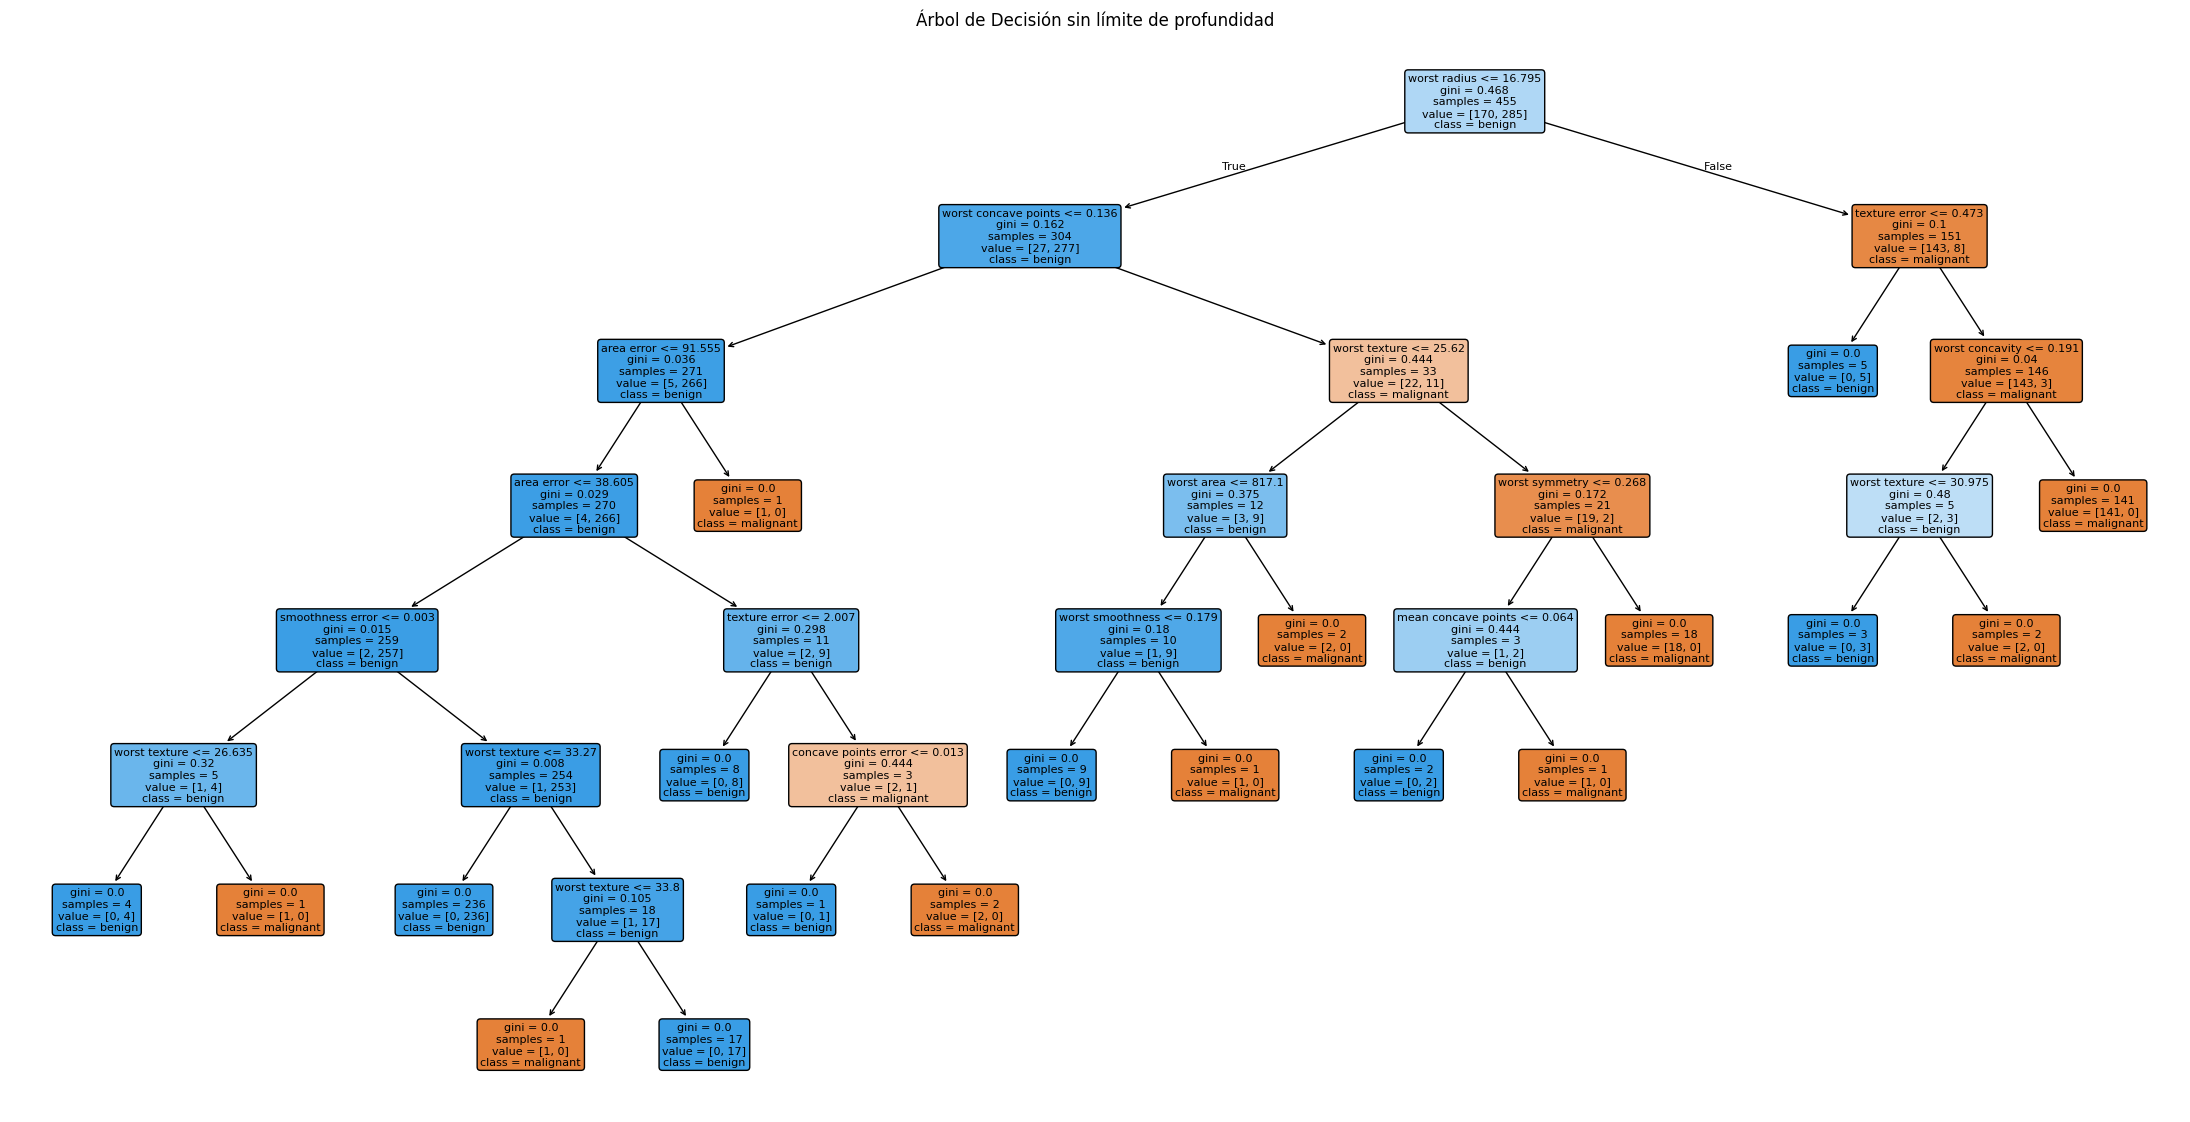

In [40]:
# ---------------------------------------------------------
# Visualización del árbol sin límite de profundidad
# ---------------------------------------------------------

plt.figure(figsize=(28, 14))

plot_tree(
    arbol_sin_limite,
    feature_names=X.columns,
    class_names=datos.target_names,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Árbol de Decisión sin límite de profundidad")
plt.show()

## Comparación visual entre ambos árboles

El árbol sin límite de profundidad resulta mucho más difícil de leer que el árbol limitado.

Aunque en este caso todavía no es un árbol enorme, ya se observa una estructura más compleja, con más ramas, más divisiones y más hojas. Esto permite ver de manera visual lo que antes observamos en las tablas: el modelo sin límite construyó más reglas de decisión.

Esta mayor complejidad puede parecer una ventaja, porque el modelo tiene más capacidad para adaptarse a los datos. Sin embargo, también puede convertirse en un problema: cuanto más específico se vuelve el árbol, mayor es el riesgo de que aprenda detalles particulares del conjunto de entrenamiento y no patrones generales.

Por eso, en muchos casos no buscamos el árbol más profundo posible, sino un equilibrio entre rendimiento, interpretabilidad y capacidad de generalización.

Esta observación nos lleva a una pregunta importante:

**¿Podemos aprovechar la lógica de los árboles de decisión, pero reduciendo su inestabilidad y su tendencia al sobreajuste?**

La respuesta a esa pregunta nos permite introducir el siguiente modelo: **Random Forest**.

# Random Forest

Hasta ahora trabajamos con Árboles de Decisión individuales. Vimos que son modelos claros, visuales e interpretables, pero también observamos una limitación importante: si el árbol crece demasiado, puede ajustarse en exceso a los datos de entrenamiento.

Random Forest parte de una idea sencilla:

**en lugar de confiar en un solo árbol, podemos entrenar muchos árboles y combinar sus predicciones.**

En un problema de clasificación, cada árbol del bosque emite su predicción. Luego, el Random Forest toma la decisión final por votación: la clase más votada por los árboles es la predicción del modelo.

De esta manera, el modelo busca conservar la potencia de los árboles de decisión, pero reduciendo su inestabilidad y su tendencia al sobreajuste.

## ¿Cómo logra diversidad un Random Forest?

Un Random Forest no entrena muchos árboles idénticos. Para que el conjunto sea útil, necesita que cada árbol tenga cierta diversidad.

Esa diversidad se logra principalmente de dos maneras:

**1. Muestreo con reemplazo**

Cada árbol se entrena con una muestra aleatoria del conjunto de entrenamiento. Esta muestra se toma **con reemplazo**, lo que significa que algunos registros pueden aparecer más de una vez y otros pueden quedar afuera.

Este procedimiento se conoce como **bootstrap**.

**2. Selección aleatoria de variables**

En cada división del árbol, el modelo no evalúa necesariamente todas las variables disponibles. En cambio, considera solo un subconjunto aleatorio de ellas.

Esto evita que todos los árboles tomen exactamente las mismas decisiones y ayuda a que el bosque combine puntos de vista diferentes.

Finalmente, cuando todos los árboles hicieron su predicción, el Random Forest combina sus respuestas. En clasificación, la decisión final se obtiene por **votación mayoritaria**.

## Entrenamiento de un Random Forest

Ahora vamos a entrenar un modelo usando `RandomForestClassifier`.

Para comenzar, usaremos una configuración simple:

- `n_estimators=100`: el bosque estará formado por 100 árboles.
- `random_state=42`: fijamos la semilla para que los resultados sean reproducibles.

A diferencia del árbol simple que entrenamos antes, ahora el modelo no dependerá de una única estructura de decisión, sino de la combinación de muchos árboles.

In [41]:
# ---------------------------------------------------------
# Entrenamiento de un Random Forest
# ---------------------------------------------------------

bosque = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Entrenamos el modelo con los datos de entrenamiento
bosque.fit(X_train, y_train)

print("Modelo Random Forest entrenado correctamente.")

Modelo Random Forest entrenado correctamente.


## Evaluación del Random Forest

Ahora vamos a evaluar el rendimiento del Random Forest sobre los datos de prueba.

Usaremos las mismas métricas que aplicamos al Árbol de Decisión:

- `accuracy`, para medir la proporción general de aciertos.
- `precision`, `recall` y `f1-score`, mediante `classification_report`.
- matriz de confusión, para observar aciertos y errores por clase.

Esto nos permitirá comparar ambos modelos de manera más justa.

Accuracy del Random Forest: 0.956140350877193

Reporte de clasificación:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



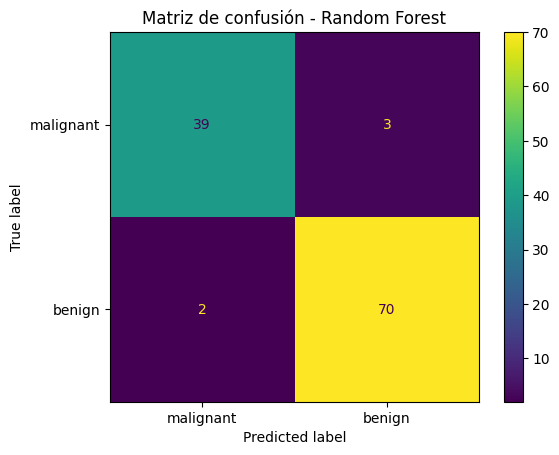

In [42]:
# ---------------------------------------------------------
# Evaluación del Random Forest
# ---------------------------------------------------------

# Generamos predicciones sobre los datos de prueba
y_pred_bosque = bosque.predict(X_test)

# Calculamos el accuracy
accuracy_bosque = accuracy_score(y_test, y_pred_bosque)

print("Accuracy del Random Forest:", accuracy_bosque)

print("\nReporte de clasificación:")
print(classification_report(
    y_test,
    y_pred_bosque,
    target_names=datos.target_names
))

# Matriz de confusión
matriz_bosque = confusion_matrix(y_test, y_pred_bosque)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_bosque,
    display_labels=datos.target_names
)

disp.plot()
plt.title("Matriz de confusión - Random Forest")
plt.show()

## Interpretación de los resultados del Random Forest

El Random Forest obtuvo un **accuracy aproximado de 0.96**, lo que representa un rendimiento muy bueno sobre el conjunto de prueba.

En comparación con el Árbol de Decisión simple, el bosque logró una mejora en el desempeño general. Además, el reporte de clasificación muestra valores altos de `precision`, `recall` y `f1-score` para ambas clases.

Esto sugiere que la combinación de muchos árboles permitió construir un modelo más robusto y con mejor capacidad de generalización que un árbol individual.

## Algunos árboles dentro del bosque

Aunque el Random Forest se comporta como un único modelo, en realidad está formado por muchos árboles de decisión.

Cada uno de esos árboles fue entrenado con cierta variación en los datos y en las variables consideradas en cada división. Por eso, los árboles del bosque **no son idénticos entre sí**.

A continuación vamos a visualizar algunos árboles del bosque. No buscamos analizarlos en detalle, sino observar que presentan estructuras diferentes.

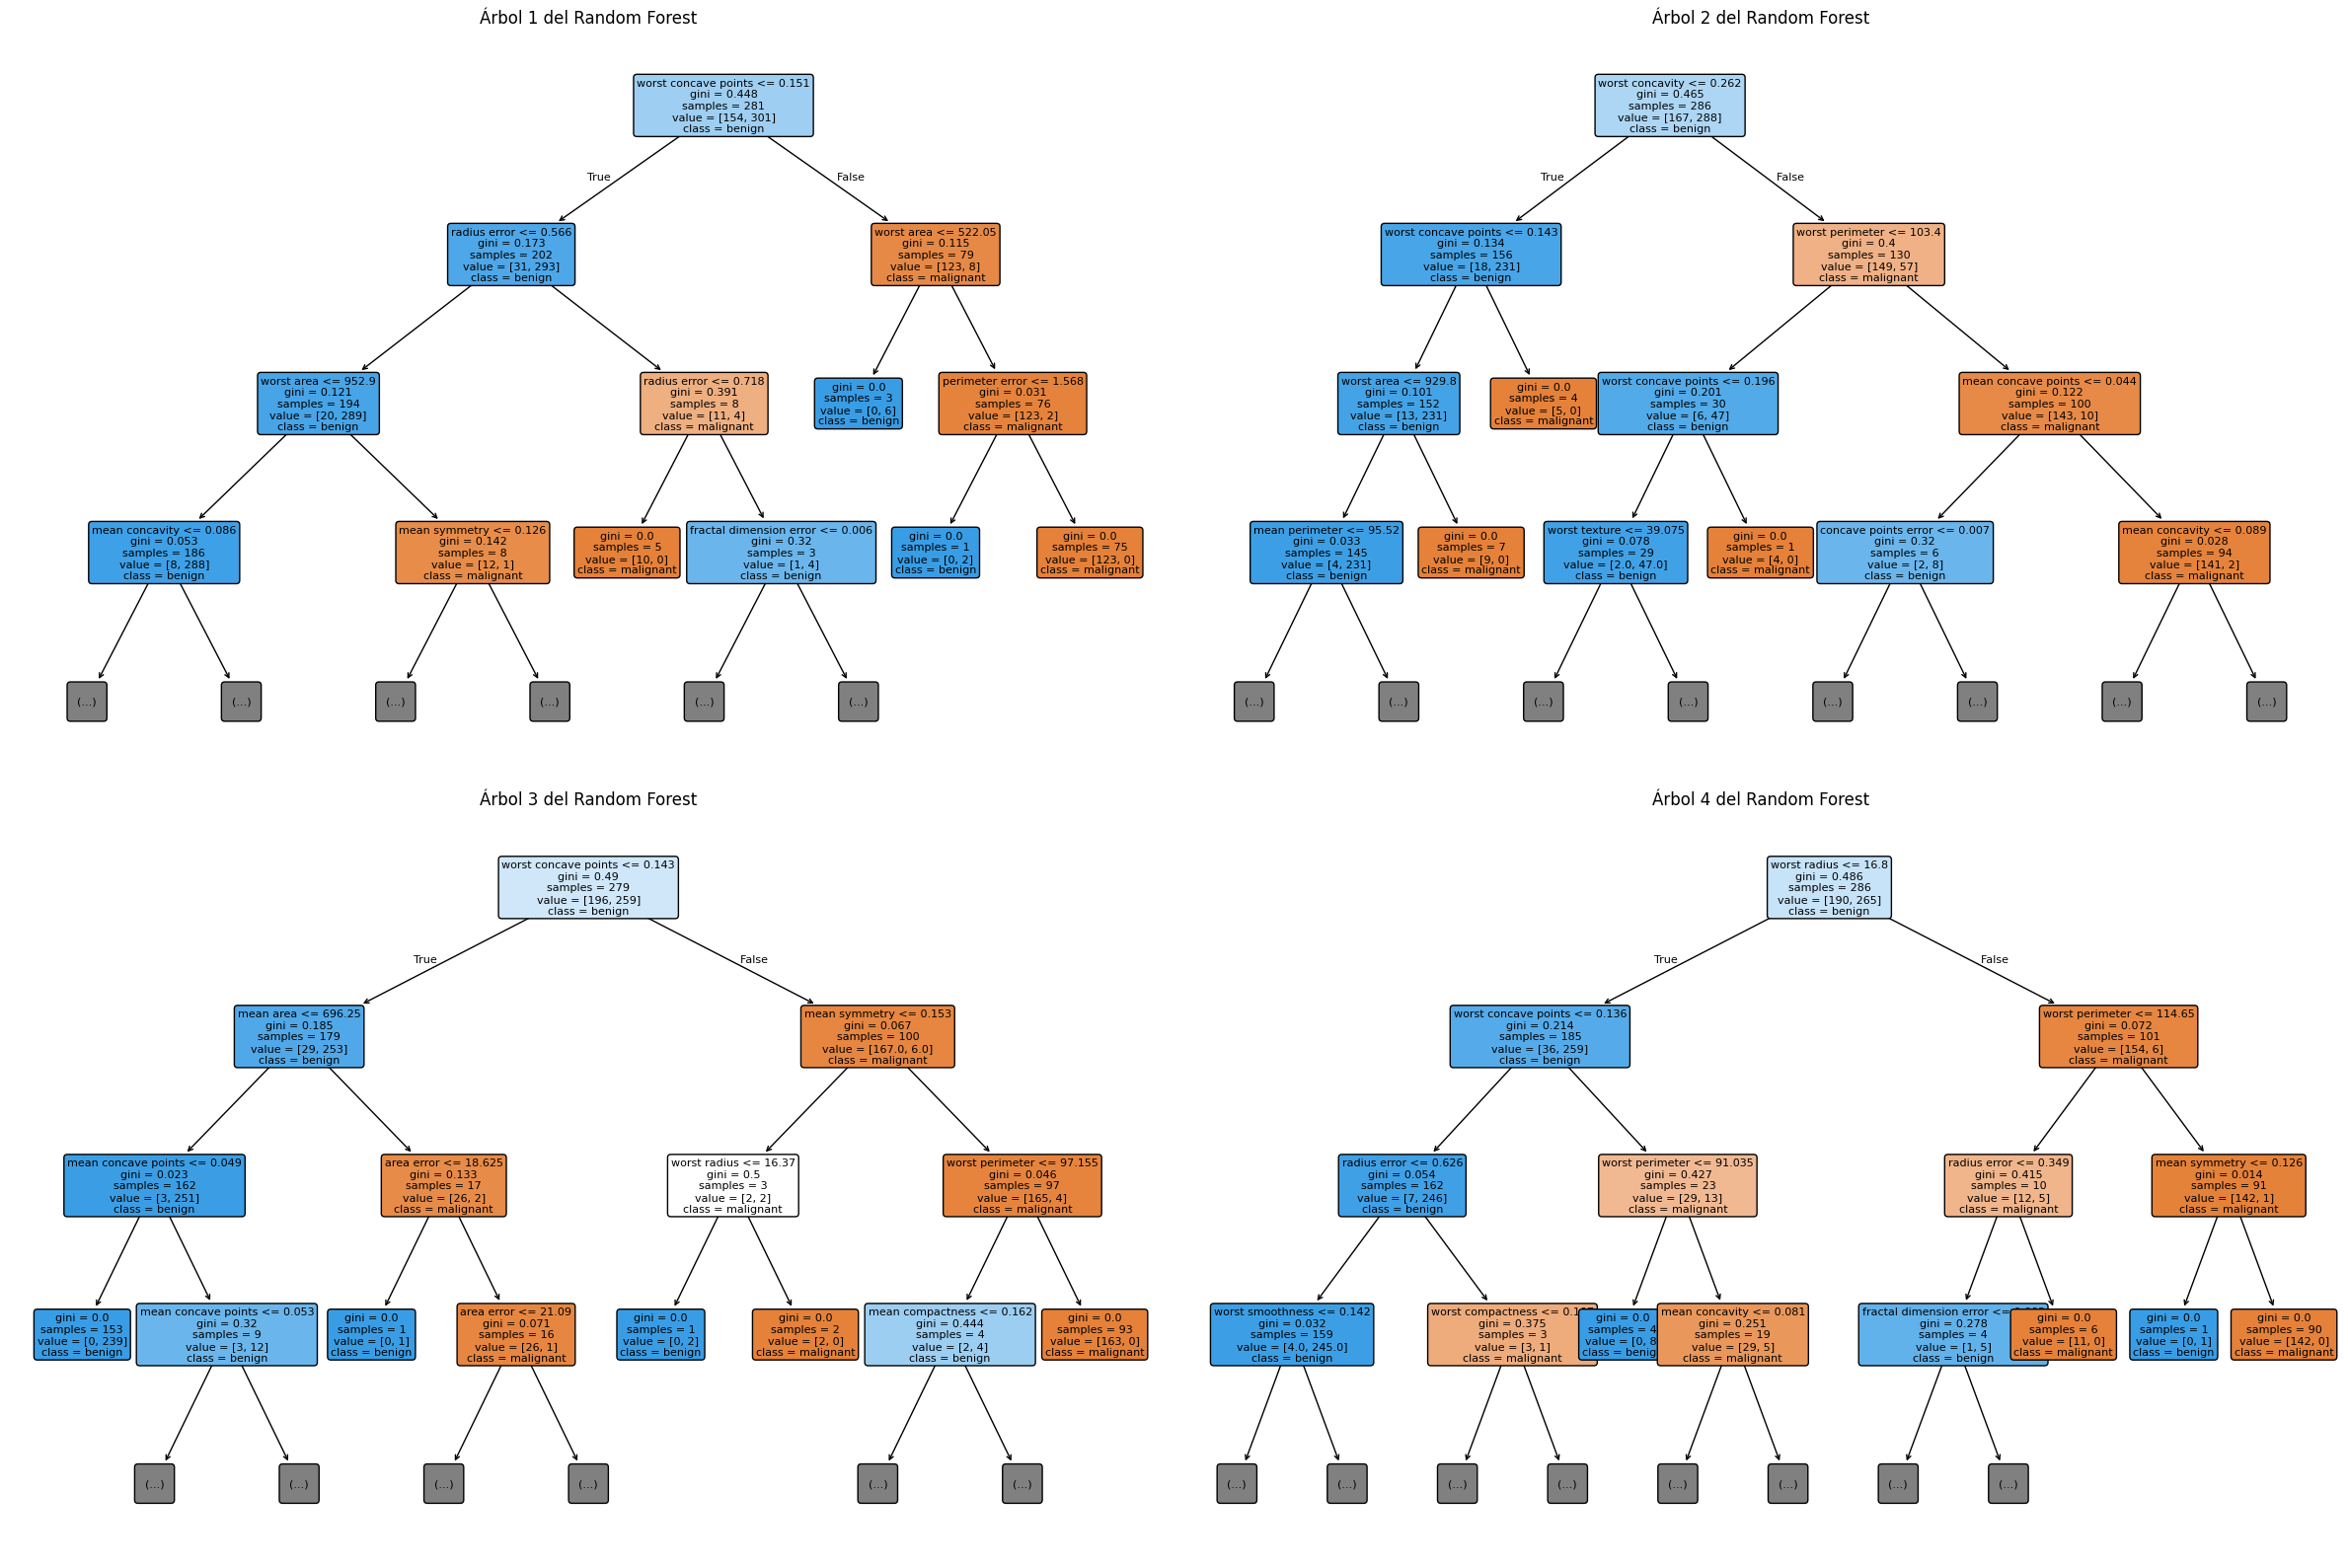

In [43]:
# ---------------------------------------------------------
# Visualización de algunos árboles del Random Forest
# ---------------------------------------------------------

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(24, 16))

for i, ax in enumerate(axes.flatten()):
    plot_tree(
        bosque.estimators_[i],
        feature_names=X.columns,
        class_names=datos.target_names,
        filled=True,
        rounded=True,
        max_depth=3,
        fontsize=8,
        ax=ax
    )
    ax.set_title(f"Árbol {i+1} del Random Forest")

plt.tight_layout()
plt.show()

## Interpretación: árboles diferentes, decisión colectiva

Los árboles que vimos forman parte del mismo Random Forest, pero no son idénticos entre sí.

Aunque todos fueron entrenados a partir del mismo conjunto original de datos, cada uno recibió una muestra diferente y consideró subconjuntos distintos de variables en sus divisiones. Por eso, sus primeras preguntas, sus ramas y sus hojas pueden cambiar.

Esta diversidad es importante: si todos los árboles fueran iguales, el bosque no aportaría demasiado más que un árbol individual. En cambio, al combinar árboles diferentes, el modelo puede compensar errores individuales.

Un árbol puede equivocarse en un caso particular, pero si la mayoría de los árboles vota correctamente, la predicción final del bosque puede ser más estable.

En clasificación, Random Forest funciona por **votación mayoritaria**:

- cada árbol realiza su propia predicción;
- cada predicción cuenta como un voto;
- la clase con más votos se convierte en la predicción final del bosque.

Por eso decimos que Random Forest no depende de una única secuencia de decisiones, sino de una decisión colectiva.

## ¿Cómo votan los árboles del bosque?

Para entender mejor cómo Random Forest toma una decisión, vamos a elegir un caso del conjunto de prueba y observar qué predice cada árbol del bosque.

Como entrenamos el modelo con `n_estimators=100`, el bosque tiene 100 árboles. Cada uno emitirá una predicción, y luego contaremos cuántos votos recibió cada clase.

La clase más votada será la predicción final del Random Forest.

In [44]:
# ---------------------------------------------------------
# Votación de los árboles para un caso particular
# ---------------------------------------------------------

# Elegimos un caso del conjunto de prueba
indice_caso = 0

# Tomamos ese caso como DataFrame para usarlo con el bosque completo
caso_df = X_test.iloc[[indice_caso]]

# Tomamos también el mismo caso como array de NumPy
# para evitar advertencias al consultar cada árbol individual
caso_array = caso_df.to_numpy()

# Cada árbol del bosque realiza su predicción
votos = []

for arbol in bosque.estimators_:
    prediccion = arbol.predict(caso_array)[0]
    votos.append(int(prediccion))

# Convertimos los votos a una Serie para contarlos
votos = pd.Series(votos)

# Contamos cuántos votos recibió cada clase
conteo_votos = votos.value_counts().sort_index()

# Nos aseguramos de mostrar ambas clases, aunque alguna tenga 0 votos
conteo_votos = conteo_votos.reindex([0, 1], fill_value=0)

# Clase real y predicción final del bosque
clase_real = int(y_test.iloc[indice_caso])
prediccion_bosque = int(bosque.predict(caso_df)[0])

print("Clase real:", datos.target_names[clase_real])
print("Predicción final del Random Forest:", datos.target_names[prediccion_bosque])

print("\nVotos de los árboles:")
for clase, cantidad in conteo_votos.items():
    print(f"{datos.target_names[int(clase)]}: {cantidad} votos")

Clase real: malignant
Predicción final del Random Forest: malignant

Votos de los árboles:
malignant: 100 votos
benign: 0 votos


## Búsqueda de un caso con votación dividida

En el ejemplo anterior, todos los árboles votaron por la misma clase. Eso muestra un caso en el que el Random Forest tomó una decisión muy segura.

Para ver mejor el mecanismo de votación, ahora vamos a buscar un caso donde los árboles estén más divididos.

La idea es recorrer los casos del conjunto de prueba, contar los votos de cada árbol y encontrar aquel donde la diferencia entre votos sea menor. Ese caso será más útil para observar cómo el bosque combina decisiones individuales.

In [45]:
# ---------------------------------------------------------
# Búsqueda de un caso con votación más dividida
# ---------------------------------------------------------

resultados_votacion = []

for indice_caso in range(len(X_test)):

    # Tomamos el caso como array para consultar árbol por árbol
    caso_array = X_test.iloc[[indice_caso]].to_numpy()

    # Predicciones de cada árbol
    votos = []

    for arbol in bosque.estimators_:
        prediccion = int(arbol.predict(caso_array)[0])
        votos.append(prediccion)

    # Contamos votos para cada clase
    votos = pd.Series(votos)
    conteo_votos = votos.value_counts().reindex([0, 1], fill_value=0)

    votos_malignant = conteo_votos[0]
    votos_benign = conteo_votos[1]

    # Calculamos la diferencia entre votos
    diferencia = abs(votos_malignant - votos_benign)

    resultados_votacion.append({
        "indice_caso": indice_caso,
        "malignant": votos_malignant,
        "benign": votos_benign,
        "diferencia": diferencia,
        "clase_real": int(y_test.iloc[indice_caso]),
        "prediccion_bosque": int(bosque.predict(X_test.iloc[[indice_caso]])[0])
    })

# Convertimos los resultados a DataFrame
df_votacion = pd.DataFrame(resultados_votacion)

# Ordenamos para encontrar los casos más divididos
df_votacion_ordenado = df_votacion.sort_values("diferencia")

# Mostramos los 10 casos con votación más pareja
df_votacion_ordenado.head(10)

,indice_caso,malignant,benign,diferencia,clase_real,prediccion_bosque
16,16,48,52,4,1,1
35,35,43,57,14,0,1
45,45,40,60,20,1,1
110,110,37,63,26,1,1
84,84,64,36,28,0,0
65,65,35,65,30,0,1
48,48,35,65,30,1,1
21,21,66,34,32,0,0
66,66,33,67,34,1,1
53,53,33,67,34,0,1


## Análisis de un caso con votación dividida

El caso con `indice_caso = 16` es especialmente útil para entender cómo decide el Random Forest.

En este caso, los votos de los árboles están muy repartidos entre las dos clases. Esto significa que no todos los árboles llegaron a la misma conclusión.

Vamos a analizarlo con más detalle para ver cuántos árboles votaron por `malignant`, cuántos por `benign`, cuál fue la clase real y cuál fue la predicción final del bosque.

In [46]:
# ---------------------------------------------------------
# Análisis detallado de un caso con votación dividida
# ---------------------------------------------------------

# Elegimos el caso con votación más pareja
indice_caso = 16

# Tomamos el caso como DataFrame para usarlo con el bosque completo
caso_df = X_test.iloc[[indice_caso]]

# Tomamos también el mismo caso como array de NumPy
# para consultar cada árbol individual sin generar advertencias
caso_array = caso_df.to_numpy()

# Cada árbol del bosque realiza su predicción
votos = []

for arbol in bosque.estimators_:
    prediccion = int(arbol.predict(caso_array)[0])
    votos.append(prediccion)

# Contamos los votos
votos = pd.Series(votos)
conteo_votos = votos.value_counts().sort_index()
conteo_votos = conteo_votos.reindex([0, 1], fill_value=0)

# Clase real y predicción final del bosque
clase_real = int(y_test.iloc[indice_caso])
prediccion_bosque = int(bosque.predict(caso_df)[0])

print("Caso analizado:", indice_caso)
print("Clase real:", datos.target_names[clase_real])
print("Predicción final del Random Forest:", datos.target_names[prediccion_bosque])

print("\nVotos de los árboles:")
for clase, cantidad in conteo_votos.items():
    print(f"{datos.target_names[int(clase)]}: {cantidad} votos")

Caso analizado: 16
Clase real: benign
Predicción final del Random Forest: benign

Votos de los árboles:
malignant: 48 votos
benign: 52 votos


## Interpretación del caso analizado

En este caso, los votos del bosque quedaron muy repartidos:

- 48 árboles votaron por `malignant`.
- 52 árboles votaron por `benign`.

La predicción final del Random Forest fue `benign`, porque esa clase obtuvo la mayoría de los votos.

Este ejemplo muestra que el modelo no necesita que todos los árboles estén de acuerdo. Cada árbol aporta una predicción individual, y el bosque toma la decisión final a partir de la clase más votada.

También permite ver que algunas predicciones pueden ser más “seguras” que otras. En un caso anterior, los 100 árboles votaron por la misma clase. En este caso, en cambio, la decisión fue mucho más ajustada.

Por eso, además de mirar la clase predicha, puede ser útil observar las probabilidades o la distribución de votos, ya que nos dan una idea del grado de acuerdo interno del modelo.

## Comparación entre Árboles de Decisión y Random Forest

Ahora vamos a comparar los tres modelos que entrenamos hasta el momento:

- un Árbol de Decisión limitado con `max_depth=3`;
- un Árbol de Decisión sin límite explícito de profundidad;
- un Random Forest con 100 árboles.

Para cada modelo vamos a calcular el `accuracy` sobre los datos de entrenamiento y sobre los datos de prueba.

Esta comparación nos permitirá observar no solo cuál modelo obtiene mejor rendimiento, sino también si aparece una diferencia importante entre entrenamiento y prueba, lo que podría ser una señal de sobreajuste.

In [47]:
# ---------------------------------------------------------
# Comparación general de modelos
# ---------------------------------------------------------

# Predicciones del Random Forest en entrenamiento y prueba
y_pred_train_bosque = bosque.predict(X_train)
y_pred_test_bosque = bosque.predict(X_test)

# Creamos una tabla comparativa
comparacion_modelos = pd.DataFrame({
    "modelo": [
        "Árbol max_depth=3",
        "Árbol sin límite",
        "Random Forest"
    ],
    "accuracy_train": [
        accuracy_score(y_train, y_pred_train_simple),
        accuracy_score(y_train, y_pred_train_sin_limite),
        accuracy_score(y_train, y_pred_train_bosque)
    ],
    "accuracy_test": [
        accuracy_score(y_test, y_pred_test_simple),
        accuracy_score(y_test, y_pred_test_sin_limite),
        accuracy_score(y_test, y_pred_test_bosque)
    ]
})

comparacion_modelos

,modelo,accuracy_train,accuracy_test
0,Árbol max_depth=3,0.975824,0.938596
1,Árbol sin límite,1.000000,0.912281
2,Random Forest,1.000000,0.956140


## Visualización comparativa del rendimiento de los modelos

La tabla anterior permite comparar con precisión los valores de `accuracy` en entrenamiento y prueba para cada modelo.

Sin embargo, un gráfico de barras puede facilitar una lectura más rápida de esa comparación. En particular, nos ayuda a observar:

- qué modelo obtuvo mejor rendimiento en el conjunto de prueba;
- qué modelos presentan una diferencia mayor entre entrenamiento y prueba;
- y qué señales pueden interpretarse como posible sobreajuste.

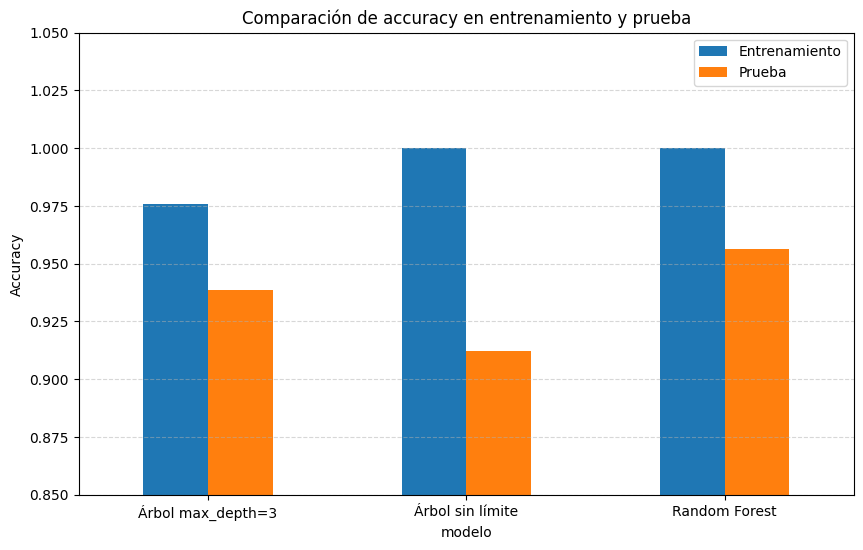

In [48]:
# ---------------------------------------------------------
# Gráfico comparativo de accuracy en train y test
# ---------------------------------------------------------

comparacion_modelos_graf = comparacion_modelos.set_index("modelo")

comparacion_modelos_graf.plot(kind="bar", figsize=(10, 6))

plt.title("Comparación de accuracy en entrenamiento y prueba")
plt.ylabel("Accuracy")
plt.ylim(0.85, 1.05)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(["Entrenamiento", "Prueba"])
plt.show()

## Interpretación del gráfico comparativo

El gráfico permite visualizar con mayor claridad las diferencias entre los modelos.

Se observa que el **Árbol sin límite** alcanza un rendimiento perfecto sobre el conjunto de entrenamiento, pero baja en el conjunto de prueba. Esto refuerza la idea de **sobreajuste**: el modelo aprendió demasiado bien los datos de entrenamiento, pero generalizó peor ante datos nuevos.

El **Árbol con `max_depth=3`** muestra un comportamiento más equilibrado: no alcanza un ajuste perfecto en entrenamiento, pero mantiene un buen rendimiento en prueba.

El **Random Forest** también logra un ajuste perfecto en entrenamiento, pero a diferencia del árbol sin límite, obtiene el mejor rendimiento sobre el conjunto de prueba. Esto sugiere que la combinación de muchos árboles permitió construir un modelo más robusto y con mejor capacidad de generalización.

## Importancia de las variables en Random Forest

Aunque Random Forest suele ser menos interpretable que un único Árbol de Decisión, todavía podemos obtener información útil sobre el modelo.

Una de las herramientas más importantes es la **importancia de las variables**.

Esta medida nos permite estimar cuánto aportó cada variable predictora a las decisiones del bosque. En términos generales, una variable será considerada más importante si aparece muchas veces en divisiones útiles dentro de los árboles y ayuda a separar mejor las clases.

A continuación vamos a obtener las importancias calculadas por el modelo y a mostrar las variables más relevantes.

In [49]:
# ---------------------------------------------------------
# Importancia de variables en Random Forest
# ---------------------------------------------------------

# Obtenemos la importancia asignada por el modelo a cada variable
importancias = bosque.feature_importances_

# Creamos un DataFrame para organizar los resultados
df_importancias = pd.DataFrame({
    "variable": X.columns,
    "importancia": importancias
})

# Ordenamos de mayor a menor importancia
df_importancias = df_importancias.sort_values(
    by="importancia",
    ascending=False
)

# Mostramos las 10 variables más importantes
df_importancias.head(10)

,variable,importancia
23,worst area,0.140016
27,worst concave points,0.129530
20,worst radius,0.097696
7,mean concave points,0.090885
22,worst perimeter,0.072226
2,mean perimeter,0.069574
0,mean radius,0.068676
6,mean concavity,0.057638
3,mean area,0.049172
26,worst concavity,0.034340


## Gráfico de importancia de variables

La tabla anterior muestra las variables más importantes según el Random Forest.

Para facilitar la interpretación, vamos a representar las 10 variables más relevantes en un gráfico de barras horizontal.

En este gráfico, las variables con barras más largas son aquellas que tuvieron mayor peso en las decisiones del modelo.

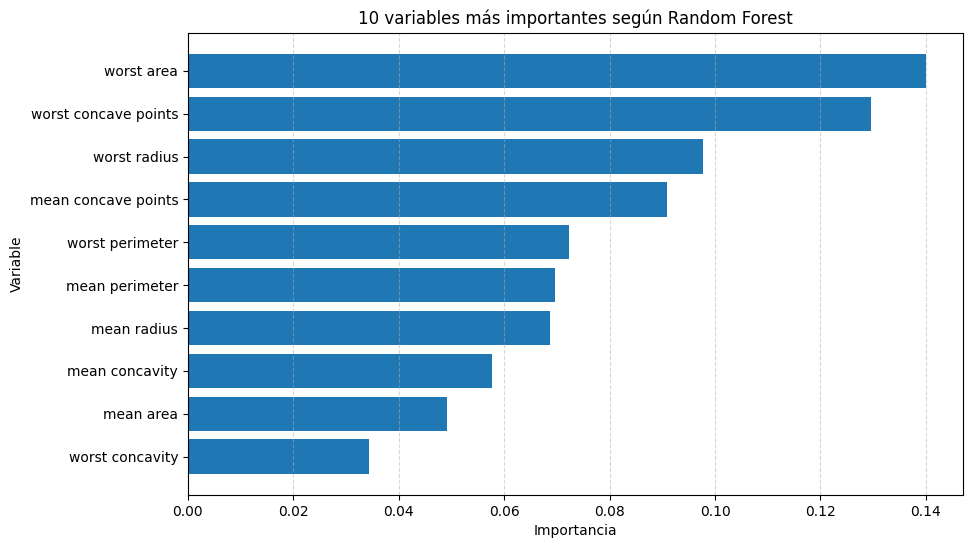

In [50]:
# ---------------------------------------------------------
# Gráfico de importancia de variables
# ---------------------------------------------------------

# Tomamos las 10 variables más importantes
top_importancias = df_importancias.head(10)

# Ordenamos de menor a mayor para que la más importante quede arriba en el gráfico
top_importancias = top_importancias.sort_values("importancia")

plt.figure(figsize=(10, 6))

plt.barh(
    top_importancias["variable"],
    top_importancias["importancia"]
)

plt.title("10 variables más importantes según Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

## Interpretación de la importancia de variables

El gráfico muestra que el Random Forest no utilizó todas las variables con el mismo peso.

Las variables más importantes están relacionadas principalmente con mediciones del tamaño, el perímetro, el área y los puntos cóncavos del tumor. Esto significa que, para este modelo, esas mediciones fueron especialmente útiles para separar los casos benignos de los malignos.

Es importante recordar que esta importancia no significa necesariamente causalidad. El modelo no está explicando por qué ocurre una enfermedad, sino qué variables fueron más útiles para mejorar sus divisiones internas y realizar predicciones.

Esta información ayuda a interpretar un modelo que, al estar formado por muchos árboles, no puede leerse tan fácilmente como un único Árbol de Decisión.

## Experimento: cantidad de árboles del bosque

Uno de los hiperparámetros más importantes de Random Forest es `n_estimators`.

Este parámetro indica cuántos árboles tendrá el bosque.

En general, usar más árboles puede hacer que el modelo sea más estable, porque la decisión final se apoya en más votos. Sin embargo, también aumenta el costo computacional, ya que entrenar y consultar más árboles requiere más tiempo y memoria.

A continuación vamos a entrenar varios modelos Random Forest con distinta cantidad de árboles y compararemos su rendimiento.

In [51]:
# ---------------------------------------------------------
# Comparación de Random Forest con distinta cantidad de árboles
# ---------------------------------------------------------

# Cantidades de árboles que vamos a probar
# cantidades_arboles = [10, 50, 100, 200]
# cantidades_arboles = [3,5,10,20,30, 50, 100, 200]

# Lista para guardar los resultados
resultados_estimadores = []

for cantidad in cantidades_arboles:

    # Creamos el modelo
    modelo_rf = RandomForestClassifier(
        n_estimators=cantidad,
        random_state=42
    )

    # Entrenamos el modelo
    modelo_rf.fit(X_train, y_train)

    # Generamos predicciones
    y_pred_train = modelo_rf.predict(X_train)
    y_pred_test = modelo_rf.predict(X_test)

    # Guardamos los resultados
    resultados_estimadores.append({
        "n_estimators": cantidad,
        "accuracy_train": accuracy_score(y_train, y_pred_train),
        "accuracy_test": accuracy_score(y_test, y_pred_test)
    })

# Convertimos los resultados en un DataFrame
df_estimadores = pd.DataFrame(resultados_estimadores)

df_estimadores

,n_estimators,accuracy_train,accuracy_test
0,3,0.984615,0.947368
1,5,0.991209,0.938596
2,10,0.995604,0.938596
3,20,1.000000,0.956140
4,30,1.000000,0.947368
5,50,1.000000,0.956140
6,100,1.000000,0.956140
7,200,1.000000,0.956140


## Visualización del efecto de `n_estimators`

La tabla anterior muestra cómo cambia el rendimiento del Random Forest al modificar la cantidad de árboles del bosque.

Para observar mejor esa variación, vamos a representar los valores de `accuracy` en un gráfico de líneas.

En este caso, el eje horizontal mostrará la cantidad de árboles y el eje vertical mostrará el rendimiento del modelo.

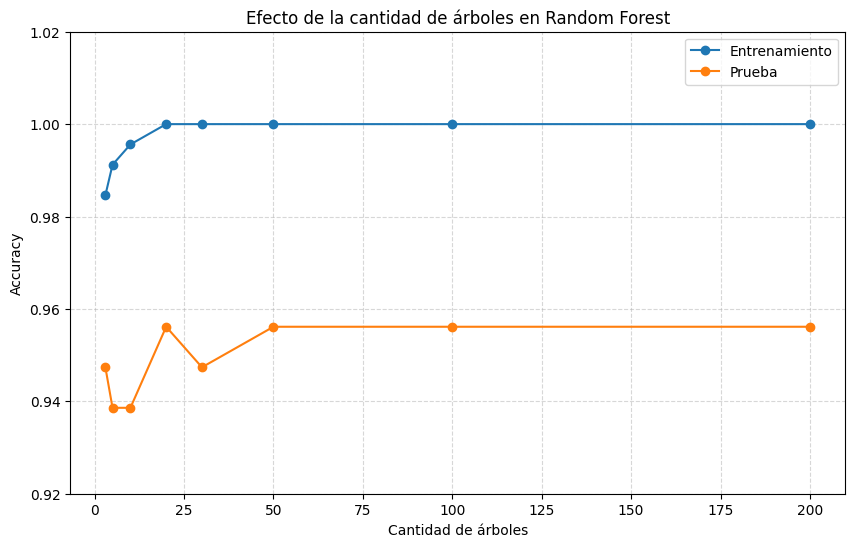

In [52]:
# ---------------------------------------------------------
# Gráfico del efecto de n_estimators
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    df_estimadores["n_estimators"],
    df_estimadores["accuracy_train"],
    marker="o",
    label="Entrenamiento"
)

plt.plot(
    df_estimadores["n_estimators"],
    df_estimadores["accuracy_test"],
    marker="o",
    label="Prueba"
)

plt.title("Efecto de la cantidad de árboles en Random Forest")
plt.xlabel("Cantidad de árboles")
plt.ylabel("Accuracy")
plt.ylim(0.92, 1.02)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.show()

## Interpretación del experimento

En este experimento observamos que el Random Forest con **10 árboles** ya obtiene un buen rendimiento, aunque menor que las versiones con más árboles.

Al aumentar la cantidad de árboles a **50**, el rendimiento en prueba mejora. Luego, con **100** y **200** árboles, el resultado se mantiene estable.

Esto muestra una idea importante: agregar más árboles puede mejorar la estabilidad del modelo, pero no siempre produce una mejora indefinida. A partir de cierto punto, sumar más árboles puede no cambiar demasiado el rendimiento, aunque sí aumenta el costo computacional.

En este caso, un bosque de 50 árboles ya logra el mismo rendimiento en prueba que los modelos con 100 y 200 árboles.

## Actividad final

A partir de lo trabajado en el cuaderno, realizá las siguientes pruebas:

1. Modificá la profundidad máxima del Árbol de Decisión usando distintos valores de `max_depth`, por ejemplo `2`, `3`, `4`, `5` y `None`.

2. Compará el rendimiento de cada árbol en entrenamiento y prueba.

3. Modificá algunos hiperparámetros del Random Forest, por ejemplo:
   - `n_estimators`
   - `max_depth`
   - `min_samples_leaf`

4. Observá si el modelo mejora, empeora o se mantiene similar.

5. Escribí una breve reflexión respondiendo:

   - ¿Qué modelo obtuvo mejor rendimiento en prueba?
   - ¿Qué modelo resultó más fácil de interpretar?
   - ¿Qué señales de sobreajuste pudiste observar?
   - ¿Qué ventaja concreta aporta Random Forest frente a un único Árbol de Decisión?

# Conclusiones

En este cuaderno trabajamos con dos modelos relacionados: los **Árboles de Decisión** y los **Random Forest**.

Primero vimos que un Árbol de Decisión toma decisiones mediante una secuencia de preguntas. Cada nodo evalúa una condición, cada rama representa un camino posible y cada hoja contiene una predicción final. Esta estructura permite visualizar el modelo y seguir sus decisiones paso a paso, lo que convierte a los árboles en modelos muy interpretables.

También analizamos una de sus principales limitaciones: el **sobreajuste**. Un árbol muy profundo puede aprender con demasiado detalle los datos de entrenamiento, pero perder capacidad de generalización frente a datos nuevos. Esto se observó al comparar el árbol limitado con el árbol sin límite de profundidad.

Luego introdujimos **Random Forest**, un modelo que combina muchos árboles de decisión. En lugar de depender de un único árbol, el bosque reúne las predicciones de muchos árboles diferentes y toma la decisión final por votación mayoritaria.

Esta combinación permite construir modelos más robustos y estables. En nuestro caso, el Random Forest obtuvo el mejor rendimiento sobre el conjunto de prueba, aunque también resultó menos interpretable que un único árbol.

Finalmente, vimos que Random Forest permite analizar la **importancia de las variables**, lo que ayuda a recuperar parte de la interpretabilidad perdida al trabajar con muchos árboles.

Los Árboles de Decisión son especialmente útiles cuando necesitamos modelos claros y explicables. Random Forest, en cambio, suele ser una mejor opción cuando buscamos mayor precisión y estabilidad, aceptando que el modelo completo será más difícil de interpretar paso a paso.

----

# Apéndice: ¿qué matemática hay detrás de los Árboles de Decisión?

Durante el cuaderno trabajamos principalmente desde una mirada práctica e interpretativa: entrenamos árboles, los visualizamos, evaluamos sus resultados y luego extendimos la idea hacia Random Forest.

En este apéndice vamos a mirar con un poco más de detalle qué ocurre internamente cuando un árbol decide cómo dividir los datos.

La pregunta central es:

**¿Cómo sabe el árbol cuál es la mejor pregunta para separar los datos?**

Para responder eso, el árbol necesita medir qué tan “mezcladas” están las clases dentro de un nodo. A esa mezcla la llamamos **impureza**.

## Impureza de un nodo

Un nodo es más **puro** cuando contiene casos mayoritariamente de una sola clase.

Por ejemplo, si en un nodo hay 100 casos y los 100 pertenecen a la clase `benign`, ese nodo es completamente puro.

En cambio, si en un nodo hay 50 casos `benign` y 50 casos `malignant`, el nodo está mucho más mezclado. En ese caso, el árbol tiene más incertidumbre sobre qué clase debería predecir.

El objetivo del árbol es encontrar divisiones que generen nodos hijos más puros que el nodo original.

Dicho de otra manera: el árbol busca preguntas que ayuden a separar mejor las clases.

## Índice de Gini

El **índice de Gini** es una medida de impureza. Nos dice qué tan mezcladas están las clases dentro de un nodo.

Su valor mínimo es `0`, y ocurre cuando todos los casos del nodo pertenecen a una sola clase.

La fórmula general es:

$$ Gini = 1 - \sum_{i=1}^{k} p_i^2 $$

donde:

- $k$ es la cantidad de clases.
- $p_i$ es la proporción de casos de la clase $i$ dentro del nodo.

En un problema binario, como el de este cuaderno, hay solo dos clases: `malignant` y `benign`.

## Ejemplo de cálculo del índice de Gini

Supongamos un nodo con 100 casos:

- 80 casos pertenecen a la clase `benign`.
- 20 casos pertenecen a la clase `malignant`.

Entonces las proporciones son:

$$ p_{benign} = 0.80 $$

$$ p_{malignant} = 0.20 $$

Aplicamos la fórmula:

$$ Gini = 1 - (0.80^2 + 0.20^2) $$

$$ Gini = 1 - (0.64 + 0.04) $$

$$ Gini = 1 - 0.68 $$

$$ Gini = 0.32 $$

Este nodo no es perfectamente puro, pero está bastante dominado por una clase. Por eso su impureza no es máxima.

## Entropía

La **entropía** es otra forma de medir la impureza o incertidumbre de un nodo.

Proviene de la teoría de la información y mide cuán desordenada está la distribución de clases.

La fórmula general es:

$$ Entropía = - \sum_{i=1}^{k} p_i \log_2(p_i) $$

donde:

- $k$ es la cantidad de clases.
- $p_i$ es la proporción de casos de la clase $i$ dentro del nodo.
- $\log_2$ es el logaritmo en base 2.

Al igual que Gini, la entropía vale `0` cuando el nodo es completamente puro.

Cuando las clases están muy mezcladas, la entropía aumenta.

## Ejemplo de cálculo de entropía

Usemos el mismo ejemplo anterior:

- 80 casos `benign`.
- 20 casos `malignant`.

Las proporciones son:

$$ p_{benign} = 0.80 $$

$$ p_{malignant} = 0.20 $$

La entropía se calcula así:

$$ Entropía = - (0.80 \log_2(0.80) + 0.20 \log_2(0.20)) $$

El resultado aproximado es:

$$ Entropía \approx 0. $$

Si el nodo estuviera dividido en partes iguales, con 50 casos de una clase y 50 de la otra, la entropía sería mayor. Eso indicaría más incertidumbre.

## Ganancia de información

Cuando el árbol prueba una posible división, compara la impureza antes y después de dividir.

Una buena división es aquella que reduce la impureza total.

A esa reducción se la conoce como **ganancia de información**.

La idea general es:

$$ Ganancia = Impureza_{antes} - Impureza_{después} $$

Si la ganancia es alta, significa que la división ayudó mucho a separar las clases.

Si la ganancia es baja, significa que la división no aportó demasiado.

Por eso, en cada nodo, el árbol busca la pregunta que produzca la mayor reducción de impureza.

## Impureza ponderada después de una división

Cuando un nodo se divide en dos nodos hijos, no alcanza con mirar la impureza de cada hijo por separado.

También importa cuántos casos quedaron en cada nodo hijo.

Por ejemplo, no tiene el mismo peso un nodo hijo con 200 casos que otro con solo 5 casos.

Por eso, el árbol calcula una impureza ponderada:

$$ Impureza_{división} =
\frac{n_{izq}}{n} \cdot Impureza_{izq}
+
\frac{n_{der}}{n} \cdot Impureza_{der} $$

donde:

- $n$ es la cantidad total de casos del nodo original.
- $n_{izq}$ es la cantidad de casos del nodo izquierdo.
- $n_{der}$ es la cantidad de casos del nodo derecho.
- $Impureza_{izq}$ es la impureza del nodo izquierdo.
- $Impureza_{der}$ es la impureza del nodo derecho.

El árbol compara muchas divisiones posibles y elige aquella que deja la menor impureza ponderada.

## ¿Qué criterio usa Scikit-learn?

En `DecisionTreeClassifier`, el criterio por defecto es `gini`.

Eso significa que, si no indicamos lo contrario, el árbol usa el índice de Gini para decidir qué divisiones conviene realizar.

Por ejemplo, este modelo usa Gini:

```python
DecisionTreeClassifier(random_state=42)
```

También podríamos pedirle que use entropía:

```python
DecisionTreeClassifier(criterion="entropy", random_state=42)
```

Ambos criterios buscan algo parecido: generar divisiones que separen mejor las clases.

En muchos problemas, Gini y entropía producen resultados similares, aunque no necesariamente idénticos.





## Relación con Random Forest

Random Forest utiliza la misma lógica básica que los Árboles de Decisión.

Cada árbol del bosque realiza divisiones buscando reducir la impureza de los nodos. Para eso puede usar criterios como Gini o entropía.

La diferencia principal es que Random Forest no depende de un único árbol.

En lugar de construir una sola estructura de decisión, entrena muchos árboles con variaciones en los datos y en las variables consideradas. Luego combina sus predicciones mediante votación mayoritaria.

Por eso, la matemática interna de cada árbol sigue siendo similar, pero el resultado final suele ser más estable y menos dependiente de una única secuencia de decisiones.

## Cierre del apéndice

La matemática detrás de los árboles de decisión se basa en una idea bastante intuitiva:

**buscar preguntas que ordenen mejor los datos.**

Para eso, el árbol mide la impureza de los nodos, prueba distintas divisiones y elige aquellas que reducen mejor la mezcla entre clases.

El índice de Gini y la entropía son dos formas distintas de medir esa impureza.

Random Forest toma esta misma lógica, pero la combina muchas veces: entrena muchos árboles, permite que sean diferentes entre sí y luego reúne sus decisiones.

Así, pasamos de una única regla jerárquica a una decisión colectiva basada en muchos árboles.